In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.colors import ListedColormap, BoundaryNorm
from scipy.stats import pearsonr

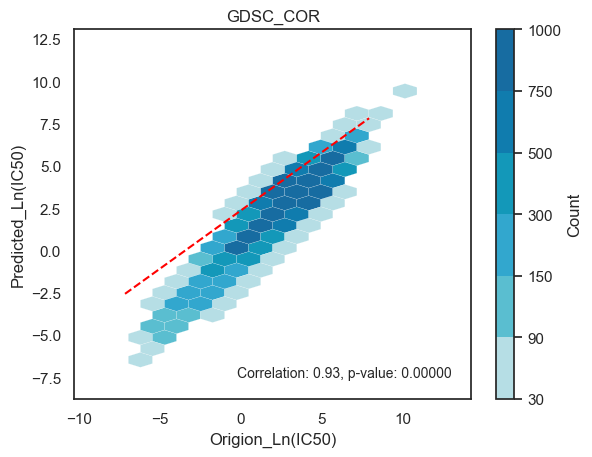

In [7]:
GDSC_IC50_pre = pd.read_csv("E:\\数据\\药物反应\\GDSC\\Results\\my_both\\IC50_CV00\\my_both__cv00_test.csv", sep=',', header=0)
GDSC_IC50 = GDSC_IC50_pre['IC50'].to_numpy()
GDSC_Pre = GDSC_IC50_pre['test_pred'].to_numpy()
sns.set(style="white")

colors = ['#B6DEE5','#5ABED0','#32A7CE','#1398B9','#107CAE','#176CA1']
boundaries = [30,90,150,300,500,750,1000]  # You can adjust these as per your data
#cmap = plt.get_cmap('Blues')  # Choose a colormap
cmap = ListedColormap(colors)
norm = BoundaryNorm(boundaries, cmap.N)

plt.hexbin(GDSC_IC50,GDSC_Pre, gridsize=(15, 15), cmap=cmap,norm=norm,mincnt=30,linewidths=0.1,edgecolors='white')
# 添加颜色条
cb = plt.colorbar()
cb.set_label('Count')

#计算相关系数
correlation, p_value = pearsonr(GDSC_IC50,GDSC_Pre)
correlation_text = f'Correlation: {correlation:.2f}, p-value: {p_value:.5f}'


# 添加相关性线条
# 添加相关性线条
mean_IC50 = np.mean(NCI60_IC50)
mean_Pre = np.mean(NCI60_Pre)
std_IC50 = np.std(NCI60_IC50)
std_Pre = np.std(NCI60_Pre)
# 计算相关系数线的斜率和截距
slope = correlation * (std_Pre / std_IC50)
intercept = mean_Pre - slope * mean_IC50

# 根据斜率和截距绘制相关系数线
x_vals = np.linspace(min(NCI60_IC50), max(NCI60_IC50), 100)
y_vals = slope * x_vals + intercept
plt.plot(x_vals, y_vals, color='red', linestyle='dashed', label=f'Correlation Line: {correlation:.2f}')
plt.text(0.95, 0.05, correlation_text, ha='right', va='bottom', transform=plt.gca().transAxes, fontsize=10, bbox=dict(facecolor='white', alpha=0.7))
# 设置标题和标签
plt.title('GDSC_COR')
plt.xlabel('Origion_Ln(IC50)')
plt.ylabel('Predicted_Ln(IC50)')

# 显示图形
plt.savefig('E:\\数据\\药物反应\\GDSC\\Results\\cor\\GDSC_IC50_cor.pdf')
plt.show()